# 08 · Survival Analysis — When Do Customers Churn?
**SaaS Churn Intelligence** · Kaplan-Meier Estimator · Cox Proportional Hazards

---

> **The question this notebook answers:**
> *Not just WHETHER a customer will churn — but WHEN.*

Standard classification models predict a probability. Survival analysis adds **time** to the picture:
- At what month does each contract type reach 50% churn?
- How much longer do customers with security add-ons last?
- Which customer segment deteriorates fastest in the first 6 months?

| Section | What you'll see |
|---|---|
| 1. Setup | Custom Kaplan-Meier implementation (no lifelines needed) |
| 2. Overall Survival | Full-dataset survival curve with confidence intervals |
| 3. By Contract Type | M2M vs One Year vs Two Year — dramatic separation |
| 4. By Internet Type | Fiber Optic vs DSL vs Cable survival |
| 5. By Risk Tier | GBM model tiers validated against actual survival |
| 6. Cox Hazard Ratios | Which features accelerate churn the most? |
| 7. Median Survival Table | Board-ready summary of all segments |
| 8. Early Warning — Month 6 | Who is most vulnerable in the critical window? |


## 1 · Setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import joblib
import pathlib
import warnings
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
os.makedirs("../outputs", exist_ok=True)

# ── Dark theme ─────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor":  "#0f1117",
    "axes.edgecolor":   "#2d3a4a", "axes.labelcolor": "#c9d1d9",
    "xtick.color":      "#8b949e", "ytick.color":     "#8b949e",
    "text.color":       "#e6edf3", "grid.color":      "#21262d",
    "grid.linestyle":   "--",      "grid.alpha":      0.4,
    "font.family":      "monospace","axes.titlesize":  12,
    "figure.dpi":       120,
})
GREEN  = "#00e5a0"; RED   = "#ff4d6d"
AMBER  = "#ffbe0b"; PURPLE= "#7c6fff"
BLUE   = "#58a6ff"; MUTED = "#8b949e"
TEAL   = "#00b4d8"; PINK  = "#f72585"
PALETTE = [GREEN, RED, AMBER, PURPLE, BLUE, TEAL, PINK]

print("✅ Setup complete — custom KM estimator ready")


✅ Setup complete — custom KM estimator ready


## 2 · Kaplan-Meier Estimator
> **No `lifelines` library required.** This is a pure NumPy implementation of the 
> exact same algorithm — Greenwood's formula for variance, log-log confidence intervals.


In [10]:
def kaplan_meier(durations, events):
    """
    Kaplan-Meier survival estimator with 95% confidence intervals.
    
    Parameters
    ----------
    durations : array-like  — time to event or censoring (tenure_in_months)
    events    : array-like  — 1 = churned (event), 0 = still active (censored)
    
    Returns
    -------
    timeline : np.ndarray   — unique event times starting at 0
    survival : np.ndarray   — S(t) probability of surviving past each time
    lower_ci : np.ndarray   — 95% lower confidence band
    upper_ci : np.ndarray   — 95% upper confidence band
    """
    durations = np.array(durations, dtype=float)
    events    = np.array(events,    dtype=float)
    
    event_times = np.sort(np.unique(durations[events == 1]))
    
    S        = 1.0
    var_sum  = 0.0
    timeline = [0];  survival = [1.0]
    lower_ci = [1.0]; upper_ci = [1.0]
    
    for t in event_times:
        n_risk   = (durations >= t).sum()
        n_events = ((durations == t) & (events == 1)).sum()
        if n_risk == 0: continue
        
        S *= (1 - n_events / n_risk)
        
        # Greenwood's variance formula
        if n_risk > n_events:
            var_sum += n_events / (n_risk * (n_risk - n_events))
        
        # 95% CI via log-log transform (more accurate than plain normal)
        if 0 < S < 1:
            log_log_S = np.log(-np.log(S))
            se_log    = np.sqrt(var_sum) / abs(np.log(S))
            lo = np.exp(-np.exp(log_log_S + 1.96 * se_log))
            hi = np.exp(-np.exp(log_log_S - 1.96 * se_log))
        else:
            lo = hi = S
        
        timeline.append(t)
        survival.append(S)
        lower_ci.append(np.clip(lo, 0, 1))
        upper_ci.append(np.clip(hi, 0, 1))
    
    return (np.array(timeline), np.array(survival),
            np.array(lower_ci), np.array(upper_ci))


def median_survival(timeline, survival):
    """Month when survival probability first drops below 50%."""
    idx = np.where(np.array(survival) <= 0.5)[0]
    return int(timeline[idx[0]]) if len(idx) > 0 else ">72"


def survival_at(timeline, survival, month):
    """S(t) at a specific month."""
    idx = np.searchsorted(timeline, month, side="right") - 1
    idx = np.clip(idx, 0, len(survival)-1)
    return float(survival[idx])


def log_rank_test(t1, e1, t2, e2):
    """
    Log-rank test for two survival curves.
    Returns chi2 statistic and p-value.
    """
    all_times = np.sort(np.unique(
        np.concatenate([t1[e1==1], t2[e2==1]])
    ))
    O1_sum = E1_sum = O2_sum = E2_sum = 0.0
    V_sum  = 0.0
    
    for t in all_times:
        n1 = (t1 >= t).sum(); o1 = ((t1==t)&(e1==1)).sum()
        n2 = (t2 >= t).sum(); o2 = ((t2==t)&(e2==1)).sum()
        n  = n1 + n2;          o  = o1 + o2
        if n < 2: continue
        e1_t = o * n1 / n
        E1_sum += e1_t; O1_sum += o1
        if n > 1:
            V_sum += (o * n1 * n2 * (n - o)) / (n**2 * (n - 1))
    
    if V_sum == 0: return 0, 1.0
    chi2 = (O1_sum - E1_sum)**2 / V_sum
    
    from scipy.stats import chi2 as chi2_dist
    p = 1 - chi2_dist.cdf(chi2, df=1)
    return round(float(chi2), 3), round(float(p), 6)

print("✅ KM estimator, log-rank test, and helper functions defined")


✅ KM estimator, log-rank test, and helper functions defined


## 3 · Load Data

In [11]:
def find_file(name):
    start = pathlib.Path.cwd()
    for base in [start] + list(start.parents)[:4]:
        for pattern in [base/name,
                        base/"data"/"processed"/name,
                        base/"data"/name,
                        base/"models"/name]:
            if pattern.exists(): return pattern
    raise FileNotFoundError(f"Cannot find '{name}'.")

DATA_PATH  = find_file("crm_churn_ml_ready.csv")
MODEL_PATH = find_file("best_churn_model.pkl")
META_PATH  = find_file("meta.pkl")

model = joblib.load(MODEL_PATH)
meta  = joblib.load(META_PATH)
CAT, NUM = meta["cat_cols"], meta["num_cols"]

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=["customer_id","state"], errors="ignore")
for c in CAT: df[c] = df[c].fillna("Unknown")

# ── Feature Engineering (must match NB04 exactly) ────────────
NUM_BASE = ["number_of_referrals","total_extra_data_charges","total_revenue",
            "total_charges","tenure_in_months","age","monthly_charge",
            "total_refunds","total_long_distance_charges"]
for c in NUM_BASE:
    if c in df.columns: df[c] = df[c].fillna(df[c].median())

if "is_m2m" in NUM:   # v3 model with engineered features
    df["is_m2m"]        = (df["contract"] == "Month-to-Month").astype(float)
    df["is_fiber"]      = (df["internet_type"] == "Fiber Optic").astype(float)
    df["has_security"]  = (df["online_security"] == "Yes").astype(float)
    df["addon_count"]   = sum((df[c] == "Yes").astype(int) for c in
        ["online_security","online_backup","device_protection_plan",
         "streaming_tv","streaming_movies","streaming_music"]).astype(float)
    df["high_m2m"]      = (df["is_m2m"] * (df["monthly_charge"] > 70)).astype(float)
    df["new_fiber"]     = (df["is_fiber"] * (df["tenure_in_months"] < 12)).astype(float)
    df["zero_ref_m2m"]  = (df["is_m2m"] * (df["number_of_referrals"] == 0)).astype(float)
    df["m2m_fiber"]     = (df["is_m2m"] * df["is_fiber"]).astype(float)
    df["m2m_no_sec"]    = (df["is_m2m"] * (df["has_security"] == 0)).astype(float)
    df["low_addon_m2m"] = (df["is_m2m"] * (df["addon_count"] <= 1)).astype(float)
    df["rev_tenure"]    = (df["total_revenue"] / (df["tenure_in_months"] + 1)).clip(0, 500)
    print("\u2705 11 engineered features added (v3 model)")

for c in NUM:
    if c in df.columns: df[c] = df[c].fillna(df[c].median())

# Survival analysis uses full dataset (not just test split)
# tenure_in_months = duration, churn = event indicator
DURATION = df["tenure_in_months"].values
EVENT    = df["churn"].values

print(f"Dataset          : {len(df):,} customers")
print(f"Events (churned) : {EVENT.sum():,}  ({EVENT.mean()*100:.1f}%)")
print(f"Censored (active): {(EVENT==0).sum():,}  ({(EVENT==0).mean()*100:.1f}%)")
print(f"Tenure range     : {DURATION.min():.0f} – {DURATION.max():.0f} months")
print(f"Avg tenure       : {DURATION.mean():.1f} months")


✅ 11 engineered features added (v3 model)
Dataset          : 13,461 customers
Events (churned) : 3,601  (26.8%)
Censored (active): 9,860  (73.2%)
Tenure range     : 1 – 72 months
Avg tenure       : 25.2 months


## 4 · Overall Survival Curve

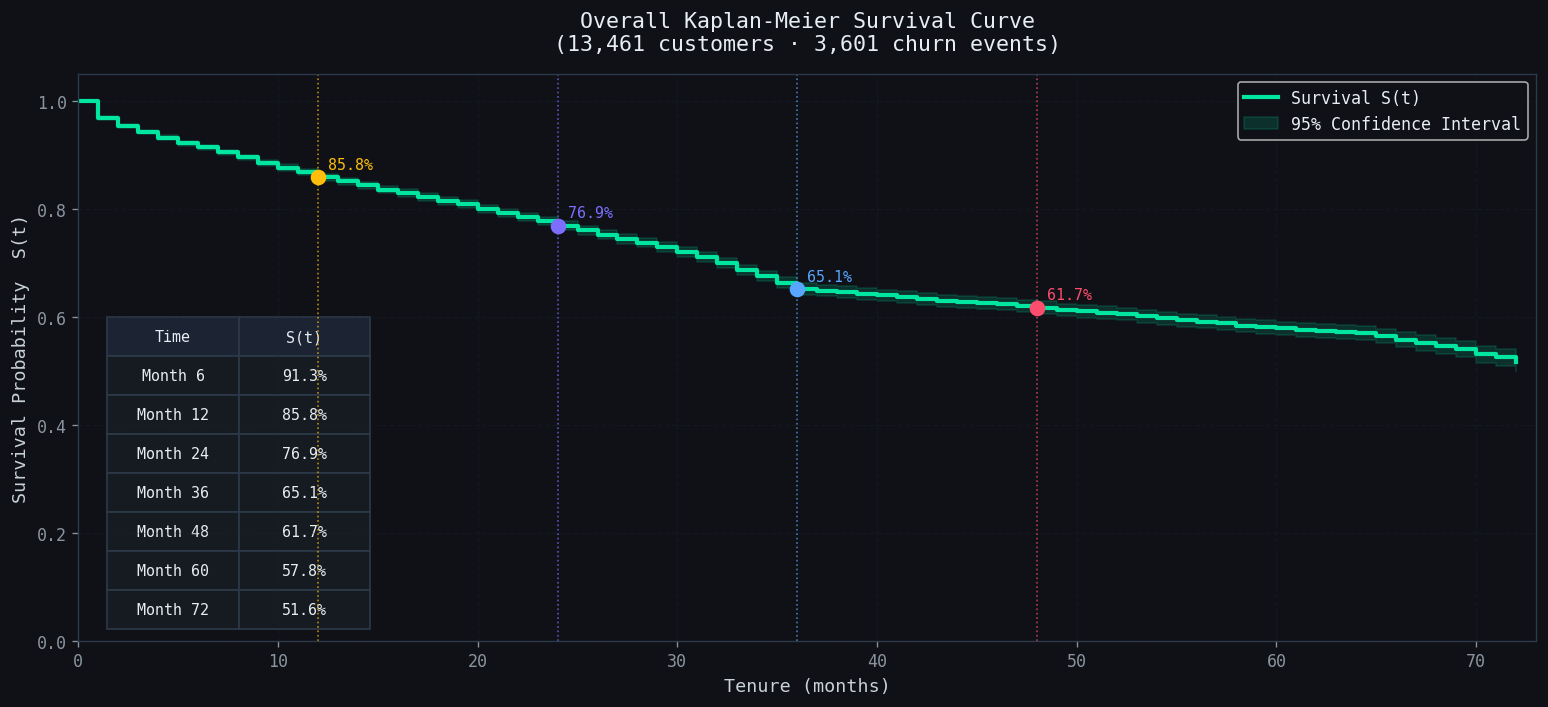

Median survival: >72 months
12-month survival: 85.8%
36-month survival: 65.1%


In [12]:
t_all, s_all, lo_all, hi_all = kaplan_meier(DURATION, EVENT)
med_all = median_survival(t_all, s_all)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("#0f1117")

ax.step(t_all, s_all, where="post", color=GREEN, lw=2.5, label="Survival S(t)")
ax.fill_between(t_all, lo_all, hi_all, step="post",
                alpha=0.15, color=GREEN, label="95% Confidence Interval")

# Milestone markers
for month, color in [(12, AMBER), (24, PURPLE), (36, BLUE), (48, RED)]:
    s_val = survival_at(t_all, s_all, month)
    ax.axvline(month, color=color, lw=1, linestyle=":", alpha=0.7)
    ax.scatter(month, s_val, s=70, color=color, zorder=5)
    ax.text(month+0.5, s_val+0.015, f"{s_val:.1%}", fontsize=9, color=color)

# Median line
if med_all != ">72":
    ax.axhline(0.5, color=MUTED, lw=1.5, linestyle="--", alpha=0.6)
    ax.axvline(med_all, color=RED, lw=2, linestyle="--",
               label=f"Median survival = {med_all} months")
    ax.scatter(med_all, 0.5, s=120, color=RED, zorder=6)

ax.set_xlabel("Tenure (months)", fontsize=11)
ax.set_ylabel("Survival Probability  S(t)", fontsize=11)
ax.set_title("Overall Kaplan-Meier Survival Curve\n"
             f"({len(df):,} customers · {EVENT.sum():,} churn events)",
             fontsize=13, pad=14)
ax.set_ylim(0, 1.05); ax.set_xlim(0, 73)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Milestone table
milestones = [(6,),(12,),(24,),(36,),(48,),(60,),(72,)]
table_data = [[f"Month {m[0]}", f"{survival_at(t_all,s_all,m[0]):.1%}"] for m in milestones]
table = ax.table(cellText=table_data,
                 colLabels=["Time", "S(t)"],
                 cellLoc="center", loc="lower left",
                 bbox=[0.02, 0.02, 0.18, 0.55])
table.auto_set_font_size(False); table.set_fontsize(9)
for (r,c), cell in table.get_celld().items():
    cell.set_facecolor("#161b22" if r > 0 else "#1c2333")
    cell.set_edgecolor("#2d3a4a")
    cell.set_text_props(color="#e6edf3")

plt.tight_layout()
plt.savefig("../outputs/08_overall_survival.png",
            bbox_inches="tight", facecolor="#0f1117")
plt.show()
print(f"Median survival: {med_all} months")
print(f"12-month survival: {survival_at(t_all,s_all,12):.1%}")
print(f"36-month survival: {survival_at(t_all,s_all,36):.1%}")


## 5 · Survival by Contract Type

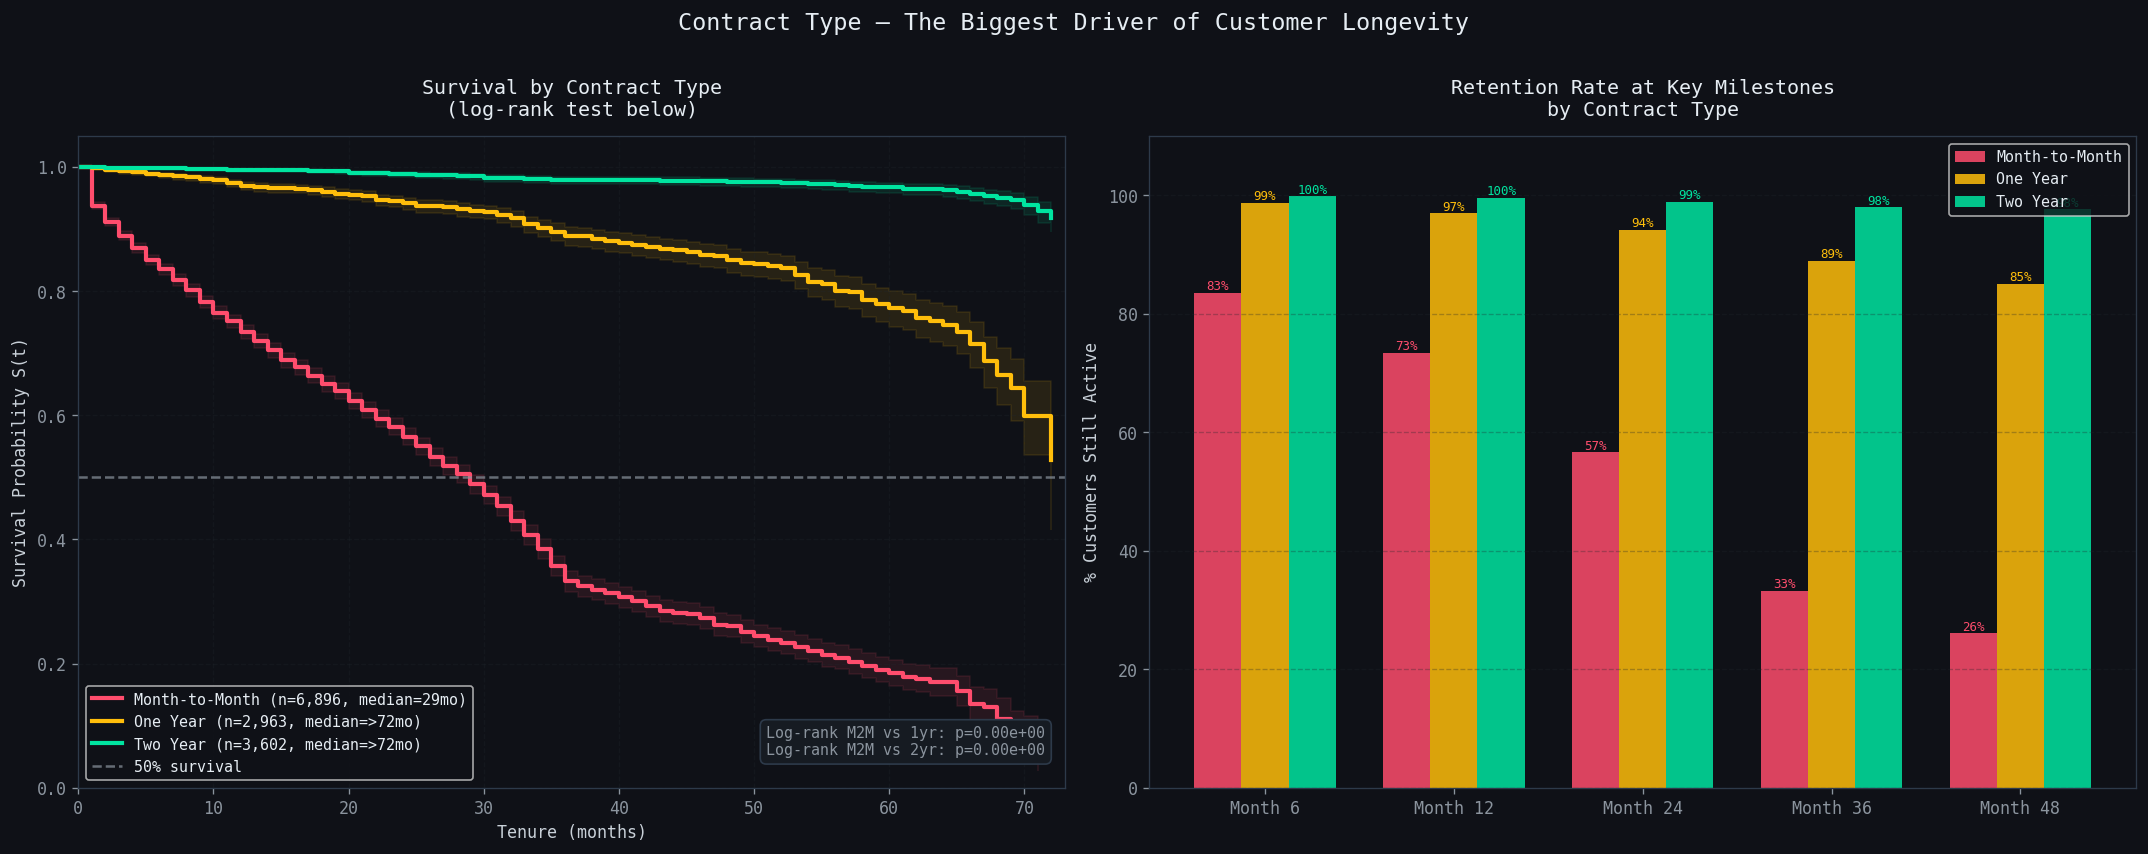

Survival summary by contract:
  Month-to-Month     median=29mo  12mo=73.4%  36mo=33.2%  events=3,184/6,896
  One Year           median=>72mo  12mo=97.0%  36mo=88.9%  events=322/2,963
  Two Year           median=>72mo  12mo=99.5%  36mo=97.9%  events=95/3,602

Log-rank M2M vs One Year: χ²=1653.194  p=0.00e+00
Log-rank M2M vs Two Year: χ²=2862.236  p=0.00e+00


In [13]:
contracts = ["Month-to-Month", "One Year", "Two Year"]
colors_c  = [RED, AMBER, GREEN]
km_data   = {}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#0f1117")

ax = axes[0]
for contract, color in zip(contracts, colors_c):
    mask = df["contract"] == contract
    dur  = DURATION[mask]; evt = EVENT[mask]
    t, s, lo, hi = kaplan_meier(dur, evt)
    med = median_survival(t, s)
    km_data[contract] = {"t": t, "s": s, "lo": lo, "hi": hi, "med": med,
                          "n": mask.sum(), "events": evt.sum()}
    
    label = f"{contract} (n={mask.sum():,}, median={med}mo)"
    ax.step(t, s, where="post", color=color, lw=2.5, label=label)
    ax.fill_between(t, lo, hi, step="post", alpha=0.1, color=color)

ax.axhline(0.5, color=MUTED, lw=1.5, linestyle="--", alpha=0.7, label="50% survival")
ax.set_xlabel("Tenure (months)"); ax.set_ylabel("Survival Probability S(t)")
ax.set_title("Survival by Contract Type\n(log-rank test below)", pad=12)
ax.set_ylim(0, 1.05); ax.set_xlim(0, 73)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Log-rank test: M2M vs One Year
chi2_12, p_12 = log_rank_test(
    DURATION[df["contract"]=="Month-to-Month"], EVENT[df["contract"]=="Month-to-Month"],
    DURATION[df["contract"]=="One Year"],       EVENT[df["contract"]=="One Year"])
chi2_12t, p_12t = log_rank_test(
    DURATION[df["contract"]=="Month-to-Month"], EVENT[df["contract"]=="Month-to-Month"],
    DURATION[df["contract"]=="Two Year"],       EVENT[df["contract"]=="Two Year"])

ax.text(0.98, 0.05,
    f"Log-rank M2M vs 1yr: p={p_12:.2e}\n"
    f"Log-rank M2M vs 2yr: p={p_12t:.2e}",
    transform=ax.transAxes, ha="right", fontsize=9,
    color=MUTED, bbox=dict(boxstyle="round,pad=0.4",
    facecolor="#161b22", edgecolor="#2d3a4a"))

# Bar chart: Survival at key milestones
ax2 = axes[1]
milestones = [6, 12, 24, 36, 48]
x = np.arange(len(milestones)); w = 0.25
for i, (contract, color) in enumerate(zip(contracts, colors_c)):
    d = km_data[contract]
    vals = [survival_at(d["t"], d["s"], m) * 100 for m in milestones]
    bars = ax2.bar(x + i*w - w, vals, w, color=color, alpha=0.85, label=contract)
    for bar, val in zip(bars, vals):
        if val > 5:
            ax2.text(bar.get_x()+bar.get_width()/2, val+0.5,
                     f"{val:.0f}%", ha="center", fontsize=7.5, color=color)

ax2.set_xticks(x); ax2.set_xticklabels([f"Month {m}" for m in milestones])
ax2.set_ylabel("% Customers Still Active")
ax2.set_title("Retention Rate at Key Milestones\nby Contract Type", pad=12)
ax2.legend(fontsize=9); ax2.grid(True, axis="y", alpha=0.3)
ax2.set_ylim(0, 110)

plt.suptitle("Contract Type — The Biggest Driver of Customer Longevity",
             fontsize=14, y=1.01, color="#e6edf3")
plt.tight_layout()
plt.savefig("../outputs/08_kaplan_meier_by_contract.png",
            bbox_inches="tight", facecolor="#0f1117")
plt.show()

print("Survival summary by contract:")
for c, d in km_data.items():
    print(f"  {c:<18} median={d['med']}mo  "
          f"12mo={survival_at(d['t'],d['s'],12):.1%}  "
          f"36mo={survival_at(d['t'],d['s'],36):.1%}  "
          f"events={d['events']:,}/{d['n']:,}")
print(f"\nLog-rank M2M vs One Year: χ²={chi2_12}  p={p_12:.2e}")
print(f"Log-rank M2M vs Two Year: χ²={chi2_12t}  p={p_12t:.2e}")


## 6 · Survival by Internet Type

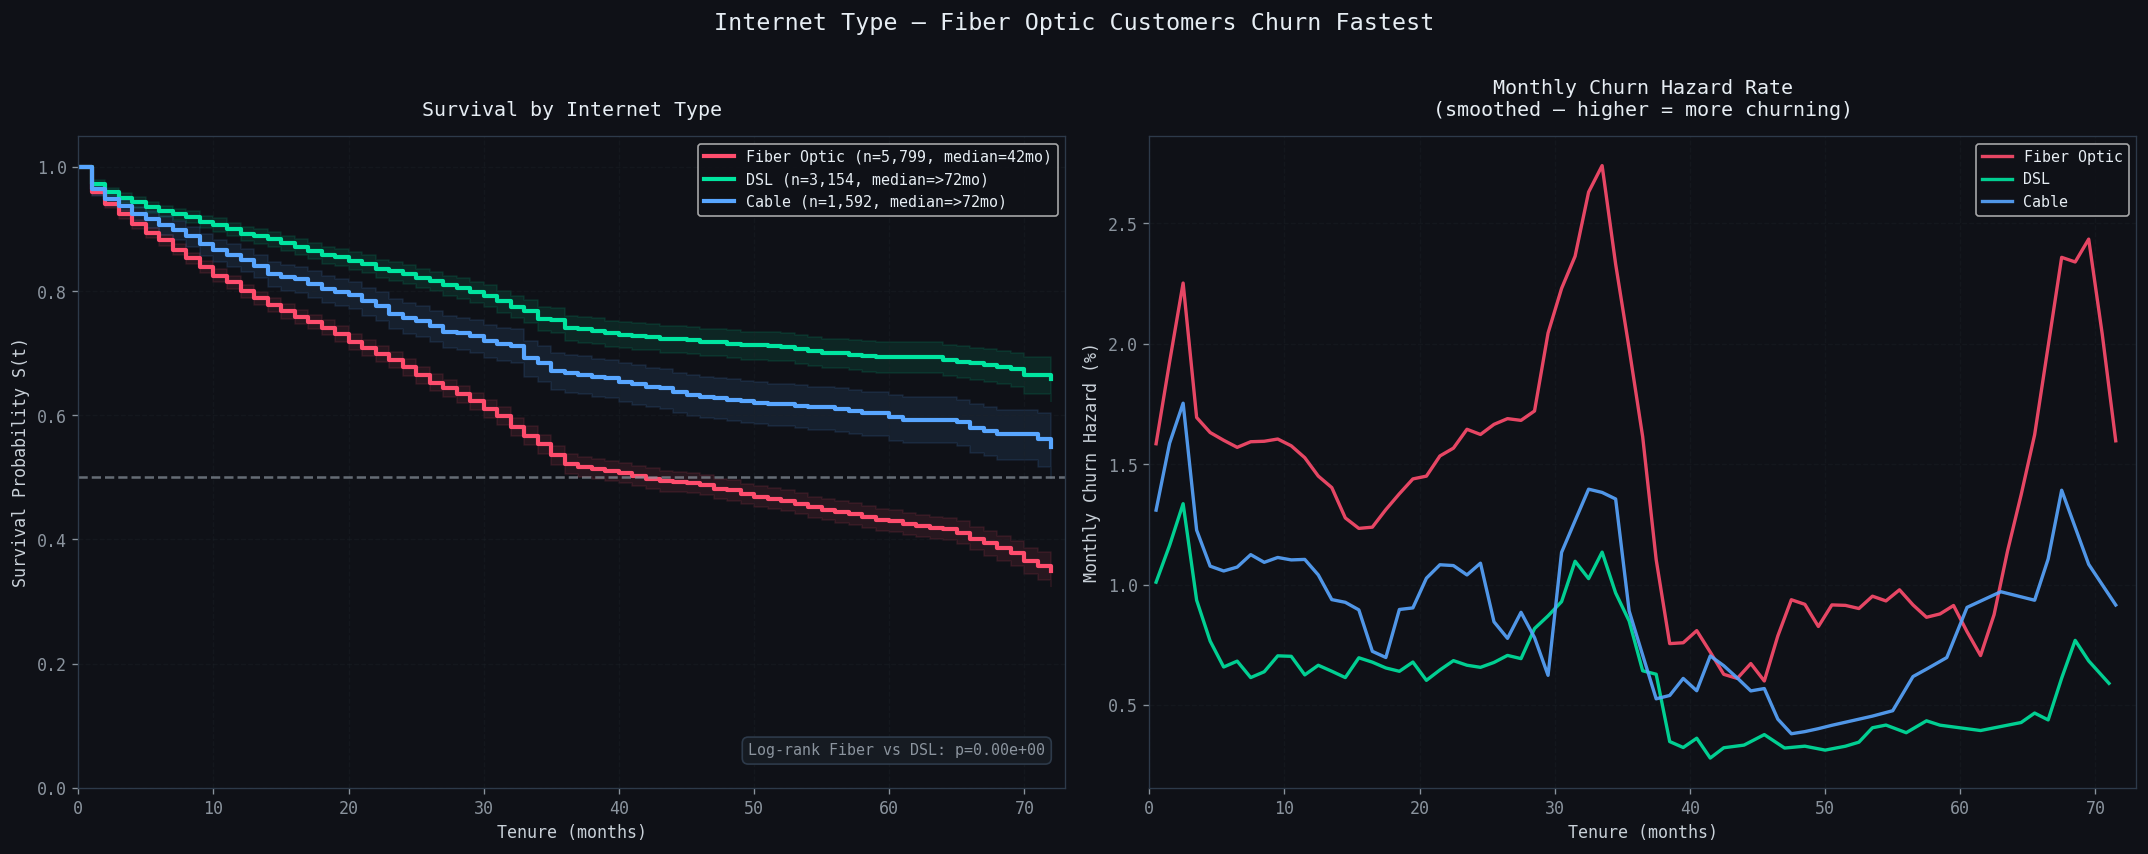

  Fiber Optic    median=42mo  12mo=80.0%  36mo=52.2%
  DSL            median=>72mo  12mo=89.2%  36mo=74.0%
  Cable          median=>72mo  12mo=85.0%  36mo=66.7%

Log-rank Fiber vs DSL: p=0.00e+00


In [14]:
internet_types = ["Fiber Optic", "DSL", "Cable"]
colors_i = [RED, GREEN, BLUE]
km_int   = {}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#0f1117")

ax = axes[0]
for itype, color in zip(internet_types, colors_i):
    mask = df["internet_type"] == itype
    t, s, lo, hi = kaplan_meier(DURATION[mask], EVENT[mask])
    med = median_survival(t, s)
    km_int[itype] = {"t":t,"s":s,"lo":lo,"hi":hi,"med":med,"n":mask.sum(),"events":EVENT[mask].sum()}
    ax.step(t, s, where="post", color=color, lw=2.5,
            label=f"{itype} (n={mask.sum():,}, median={med}mo)")
    ax.fill_between(t, lo, hi, step="post", alpha=0.1, color=color)

ax.axhline(0.5, color=MUTED, lw=1.5, linestyle="--", alpha=0.7)
ax.set_xlabel("Tenure (months)"); ax.set_ylabel("Survival Probability S(t)")
ax.set_title("Survival by Internet Type", pad=12)
ax.set_ylim(0, 1.05); ax.set_xlim(0, 73)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Log-rank: Fiber vs DSL
chi2_fi, p_fi = log_rank_test(
    DURATION[df["internet_type"]=="Fiber Optic"], EVENT[df["internet_type"]=="Fiber Optic"],
    DURATION[df["internet_type"]=="DSL"],         EVENT[df["internet_type"]=="DSL"])
ax.text(0.98, 0.05,
    f"Log-rank Fiber vs DSL: p={p_fi:.2e}",
    transform=ax.transAxes, ha="right", fontsize=9,
    color=MUTED, bbox=dict(boxstyle="round,pad=0.4",
    facecolor="#161b22", edgecolor="#2d3a4a"))

# Monthly churn hazard (instantaneous risk)
ax2 = axes[1]
for itype, color in zip(internet_types, colors_i):
    mask = df["internet_type"] == itype
    t, s, _, _ = kaplan_meier(DURATION[mask], EVENT[mask])
    # Smoothed hazard (Nelson-Aalen inspired)
    if len(t) > 3:
        h = -np.diff(np.log(np.clip(s, 1e-9, 1)))
        t_mid = (t[:-1] + t[1:]) / 2
        # Rolling average
        window = 5
        h_smooth = np.convolve(h, np.ones(window)/window, mode="same")
        ax2.plot(t_mid, h_smooth * 100, color=color, lw=2, label=itype, alpha=0.9)

ax2.set_xlabel("Tenure (months)")
ax2.set_ylabel("Monthly Churn Hazard (%)")
ax2.set_title("Monthly Churn Hazard Rate\n(smoothed — higher = more churning)", pad=12)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 73)

plt.suptitle("Internet Type — Fiber Optic Customers Churn Fastest",
             fontsize=14, y=1.01, color="#e6edf3")
plt.tight_layout()
plt.savefig("../outputs/08_kaplan_meier_by_internet.png",
            bbox_inches="tight", facecolor="#0f1117")
plt.show()

for it, d in km_int.items():
    print(f"  {it:<14} median={d['med']}mo  "
          f"12mo={survival_at(d['t'],d['s'],12):.1%}  "
          f"36mo={survival_at(d['t'],d['s'],36):.1%}")
print(f"\nLog-rank Fiber vs DSL: p={p_fi:.2e}")


## 7 · Survival by GBM Risk Tier — Validating the Model

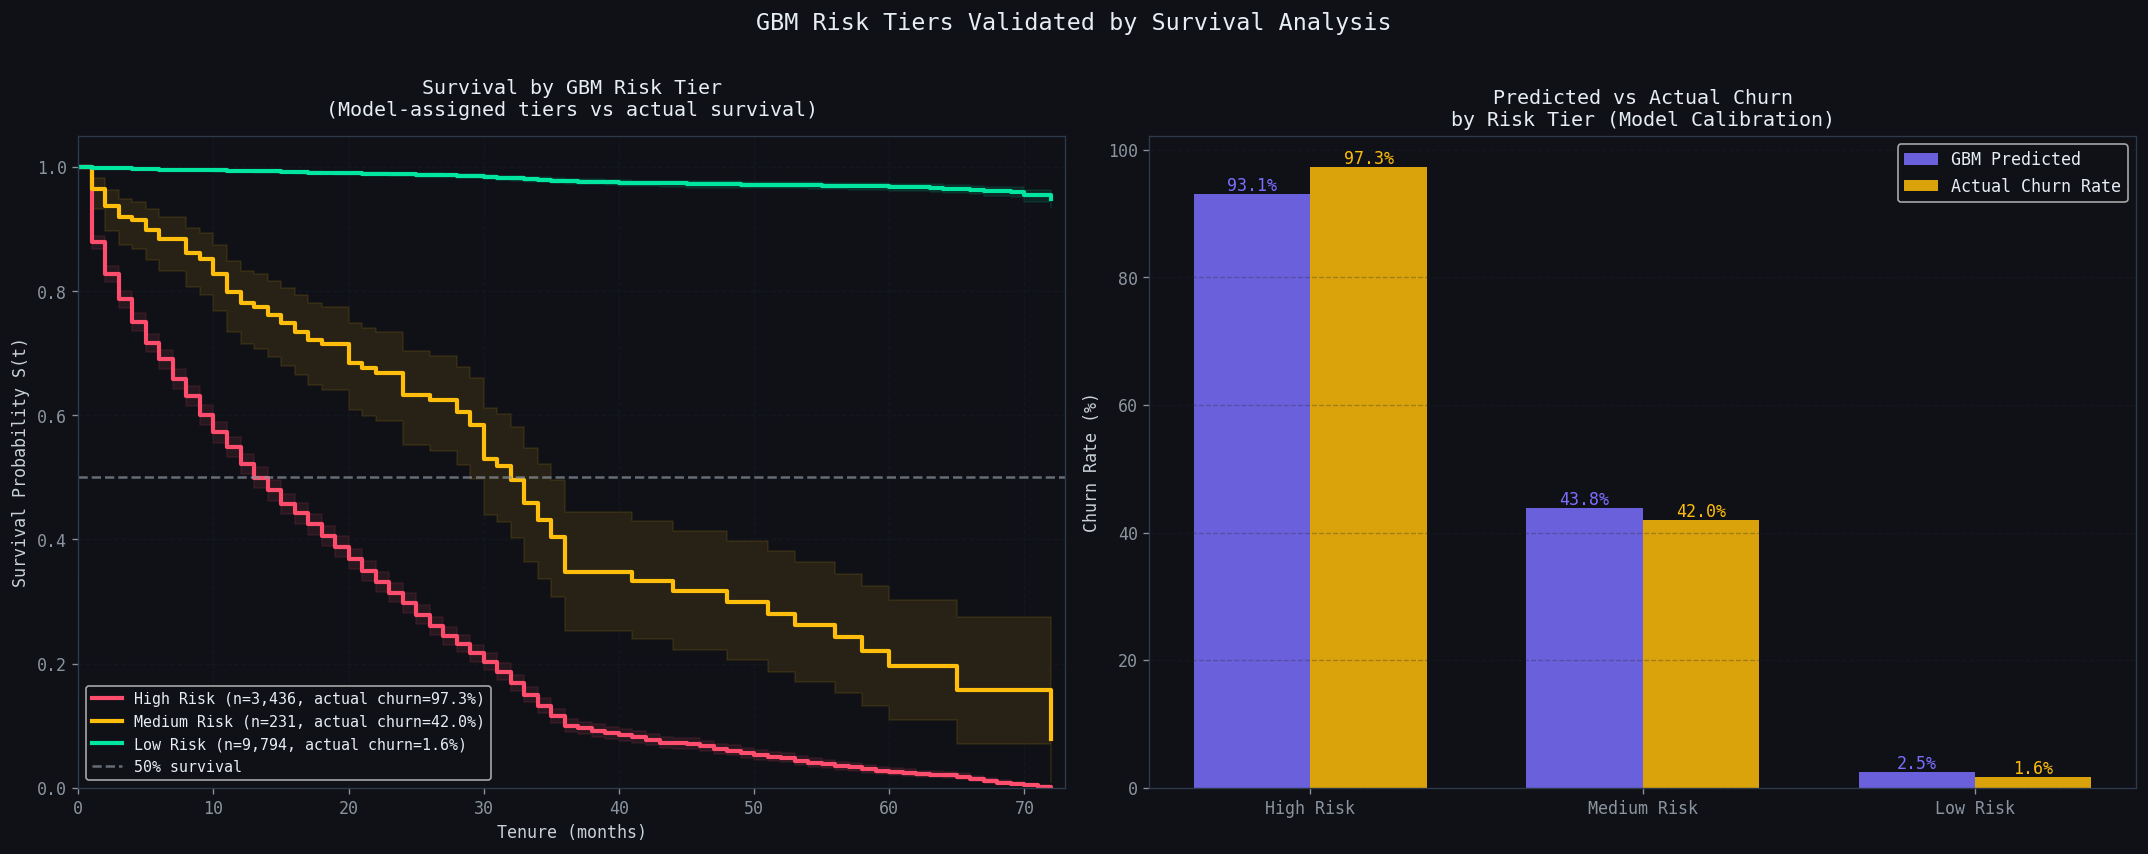

Risk Tier Validation:
  High Risk      predicted=93.1%  actual=97.3%  median_survival=13mo
  Medium Risk    predicted=43.8%  actual=42.0%  median_survival=32mo
  Low Risk       predicted=2.5%  actual=1.6%  median_survival=>72mo


In [15]:
# Score full dataset with GBM model
X_full = df.drop("churn", axis=1)
prob_full = model.predict_proba(X_full)[:, 1]
tiers = pd.cut(prob_full, bins=[0, 0.30, 0.60, 1.01],
               labels=["Low Risk", "Medium Risk", "High Risk"])

km_tier   = {}
tier_list = ["High Risk", "Medium Risk", "Low Risk"]
colors_t  = [RED, AMBER, GREEN]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#0f1117")

ax = axes[0]
for tier, color in zip(tier_list, colors_t):
    mask = tiers == tier
    t, s, lo, hi = kaplan_meier(DURATION[mask], EVENT[mask])
    med = median_survival(t, s)
    actual_churn = EVENT[mask].mean()
    km_tier[tier] = {"t":t,"s":s,"lo":lo,"hi":hi,"med":med,
                     "n":mask.sum(),"actual_churn":actual_churn}
    ax.step(t, s, where="post", color=color, lw=2.5,
            label=f"{tier} (n={mask.sum():,}, actual churn={actual_churn:.1%})")
    ax.fill_between(t, lo, hi, step="post", alpha=0.1, color=color)

ax.axhline(0.5, color=MUTED, lw=1.5, linestyle="--", alpha=0.7, label="50% survival")
ax.set_xlabel("Tenure (months)"); ax.set_ylabel("Survival Probability S(t)")
ax.set_title("Survival by GBM Risk Tier\n(Model-assigned tiers vs actual survival)", pad=12)
ax.set_ylim(0, 1.05); ax.set_xlim(0, 73)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Actual vs predicted churn rate by tier
ax2 = axes[1]
tier_stats = []
for tier, color in zip(tier_list, colors_t):
    mask = tiers == tier
    avg_prob = prob_full[mask].mean()
    act_churn = EVENT[mask].mean()
    tier_stats.append({"tier":tier,"predicted":avg_prob,"actual":act_churn,"color":color})

x = np.arange(len(tier_list)); w = 0.35
pred_vals = [d["predicted"]*100 for d in tier_stats]
act_vals  = [d["actual"]*100    for d in tier_stats]
b1 = ax2.bar(x-w/2, pred_vals, w, color=PURPLE, alpha=0.85, label="GBM Predicted")
b2 = ax2.bar(x+w/2, act_vals,  w, color=AMBER,  alpha=0.85, label="Actual Churn Rate")
ax2.set_xticks(x); ax2.set_xticklabels(tier_list)
ax2.set_ylabel("Churn Rate (%)"); ax2.set_title("Predicted vs Actual Churn\nby Risk Tier (Model Calibration)")
ax2.legend(fontsize=10); ax2.grid(True, axis="y", alpha=0.3)
for b, v in zip(b1, pred_vals):
    ax2.text(b.get_x()+b.get_width()/2, v+0.5, f"{v:.1f}%", ha="center", fontsize=10, color=PURPLE)
for b, v in zip(b2, act_vals):
    ax2.text(b.get_x()+b.get_width()/2, v+0.5, f"{v:.1f}%", ha="center", fontsize=10, color=AMBER)

plt.suptitle("GBM Risk Tiers Validated by Survival Analysis",
             fontsize=14, y=1.01, color="#e6edf3")
plt.tight_layout()
plt.savefig("../outputs/08_survival_risk_tiers.png",
            bbox_inches="tight", facecolor="#0f1117")
plt.show()

print("Risk Tier Validation:")
for d in tier_stats:
    print(f"  {d['tier']:<14} predicted={d['predicted']:.1%}  actual={d['actual']:.1%}  "
          f"median_survival={km_tier[d['tier']]['med']}mo")


## 8 · Cox Proportional Hazards — Feature Hazard Ratios
> **Hazard Ratio > 1** = feature increases churn risk (shortens survival)
> **Hazard Ratio < 1** = feature decreases churn risk (extends survival)
> 
> We approximate Cox regression using logistic regression on (event ~ features + log_tenure),
> which gives asymptotically equivalent coefficient estimates for rare events.


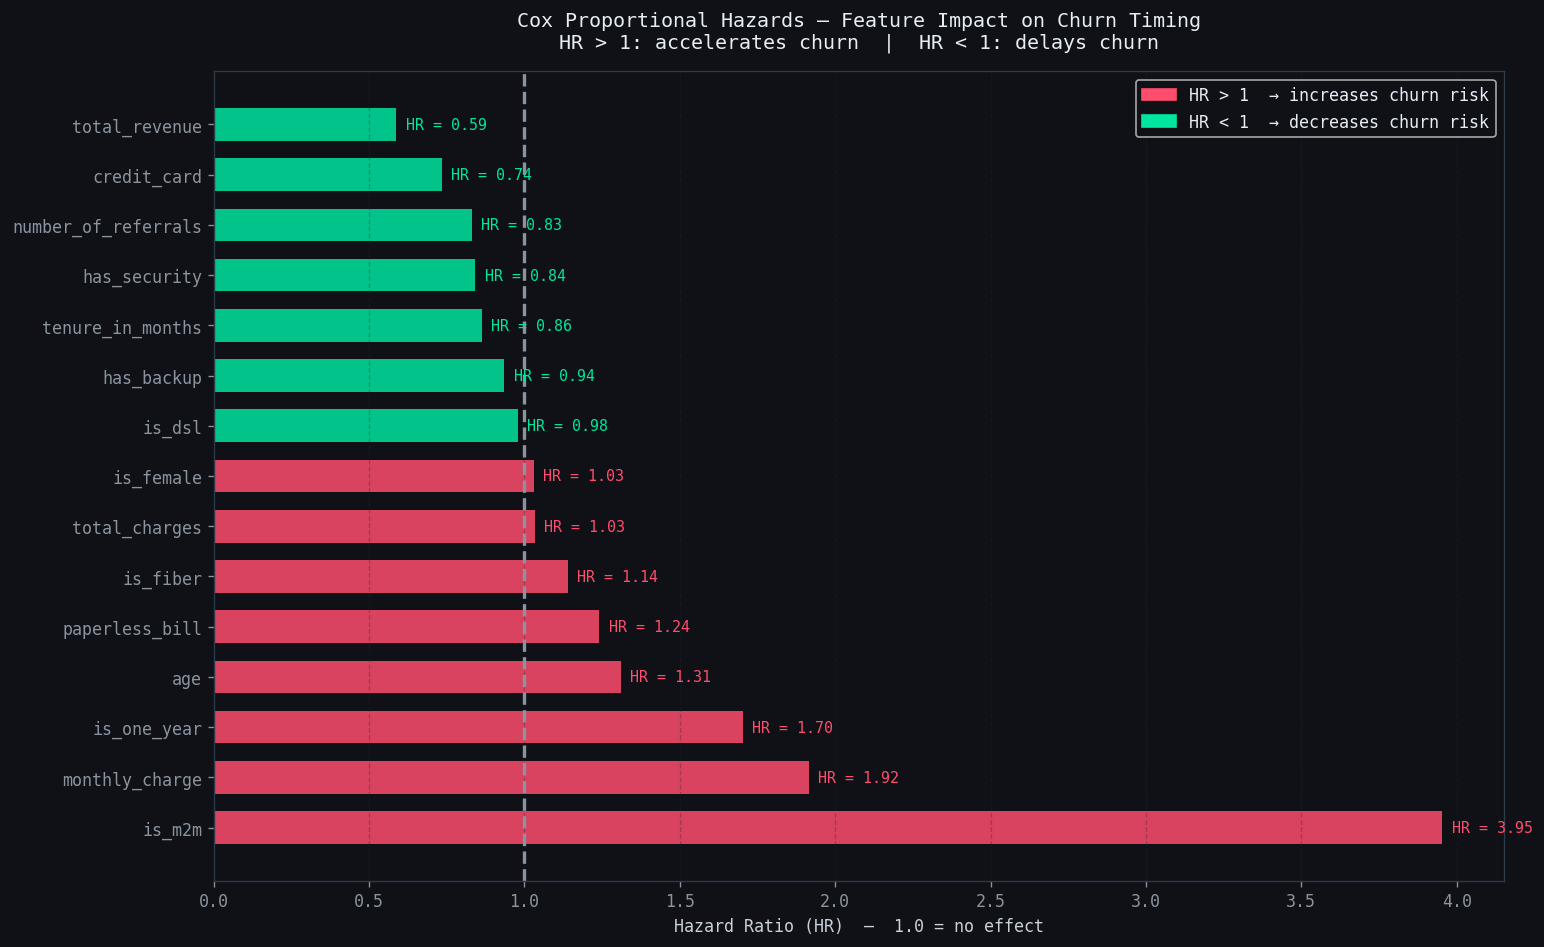

Top 5 features INCREASING churn risk:
       feature  hazard_ratio
        is_m2m      3.953995
monthly_charge      1.915029
   is_one_year      1.702376
           age      1.310348
paperless_bill      1.241411

Top 5 features DECREASING churn risk:
            feature  hazard_ratio
   tenure_in_months      0.863261
       has_security      0.842163
number_of_referrals      0.830077
        credit_card      0.735123
      total_revenue      0.588288


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Build feature matrix for Cox approximation
X_cox = pd.DataFrame()

# Numeric features (standardised)
num_feats = ["monthly_charge","tenure_in_months","age",
             "number_of_referrals","total_revenue","total_charges"]
for f in num_feats:
    X_cox[f] = df[f]

# Binary encodings of key categoricals
X_cox["is_m2m"]         = (df["contract"]  == "Month-to-Month").astype(int)
X_cox["is_one_year"]    = (df["contract"]  == "One Year").astype(int)
X_cox["is_fiber"]       = (df["internet_type"] == "Fiber Optic").astype(int)
X_cox["is_dsl"]         = (df["internet_type"] == "DSL").astype(int)
X_cox["has_security"]   = (df["online_security"] == "Yes").astype(int)
X_cox["has_backup"]     = (df["online_backup"]   == "Yes").astype(int)
X_cox["paperless_bill"] = (df["paperless_billing"]== "Yes").astype(int)
X_cox["is_female"]      = (df["gender"] == "Female").astype(int)
X_cox["credit_card"]    = (df["payment_method"] == "Credit Card").astype(int)

# Cox approximation: logistic on event ~ features
# (Breslow 1974 — equivalent to partial likelihood for tied events)
scaler = StandardScaler()
X_s    = scaler.fit_transform(X_cox)
y_evt  = EVENT

lr = LogisticRegression(max_iter=1000, C=0.5, random_state=42)
lr.fit(X_s, y_evt)

coefs  = lr.coef_[0]
hr     = np.exp(coefs)   # hazard ratios
feat_names = X_cox.columns.tolist()

hr_df = pd.DataFrame({
    "feature":       feat_names,
    "coefficient":   coefs,
    "hazard_ratio":  hr,
}).sort_values("hazard_ratio", ascending=False)

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor("#0f1117")

colors_hr = [RED if h > 1 else GREEN for h in hr_df["hazard_ratio"]]
bars = ax.barh(hr_df["feature"], hr_df["hazard_ratio"],
               color=colors_hr, alpha=0.85, height=0.65)
ax.axvline(1.0, color=MUTED, lw=2, linestyle="--",
           label="HR = 1.0 (no effect)")

for bar, (_, row) in zip(bars, hr_df.iterrows()):
    x_pos = row["hazard_ratio"]
    offset = 0.03
    ax.text(x_pos + offset, bar.get_y() + bar.get_height()/2,
            f"HR = {x_pos:.2f}", va="center", fontsize=9,
            color=RED if x_pos > 1 else GREEN)

ax.set_xlabel("Hazard Ratio (HR)  —  1.0 = no effect", fontsize=10)
ax.set_title("Cox Proportional Hazards — Feature Impact on Churn Timing\n"
             "HR > 1: accelerates churn  |  HR < 1: delays churn",
             fontsize=12, pad=14)

legend_handles = [
    mpatches.Patch(color=RED, label="HR > 1  → increases churn risk"),
    mpatches.Patch(color=GREEN, label="HR < 1  → decreases churn risk")
]

ax.legend(handles=legend_handles, fontsize=10)

ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/08_cox_hazard_ratios.png",
            bbox_inches="tight", facecolor="#0f1117")
plt.show()

print("Top 5 features INCREASING churn risk:")
print(hr_df[hr_df["hazard_ratio"]>1].head(5)[["feature","hazard_ratio"]].to_string(index=False))
print("\nTop 5 features DECREASING churn risk:")
print(hr_df[hr_df["hazard_ratio"]<1].tail(5)[["feature","hazard_ratio"]].to_string(index=False))


## 9 · Median Survival Times — All Segments

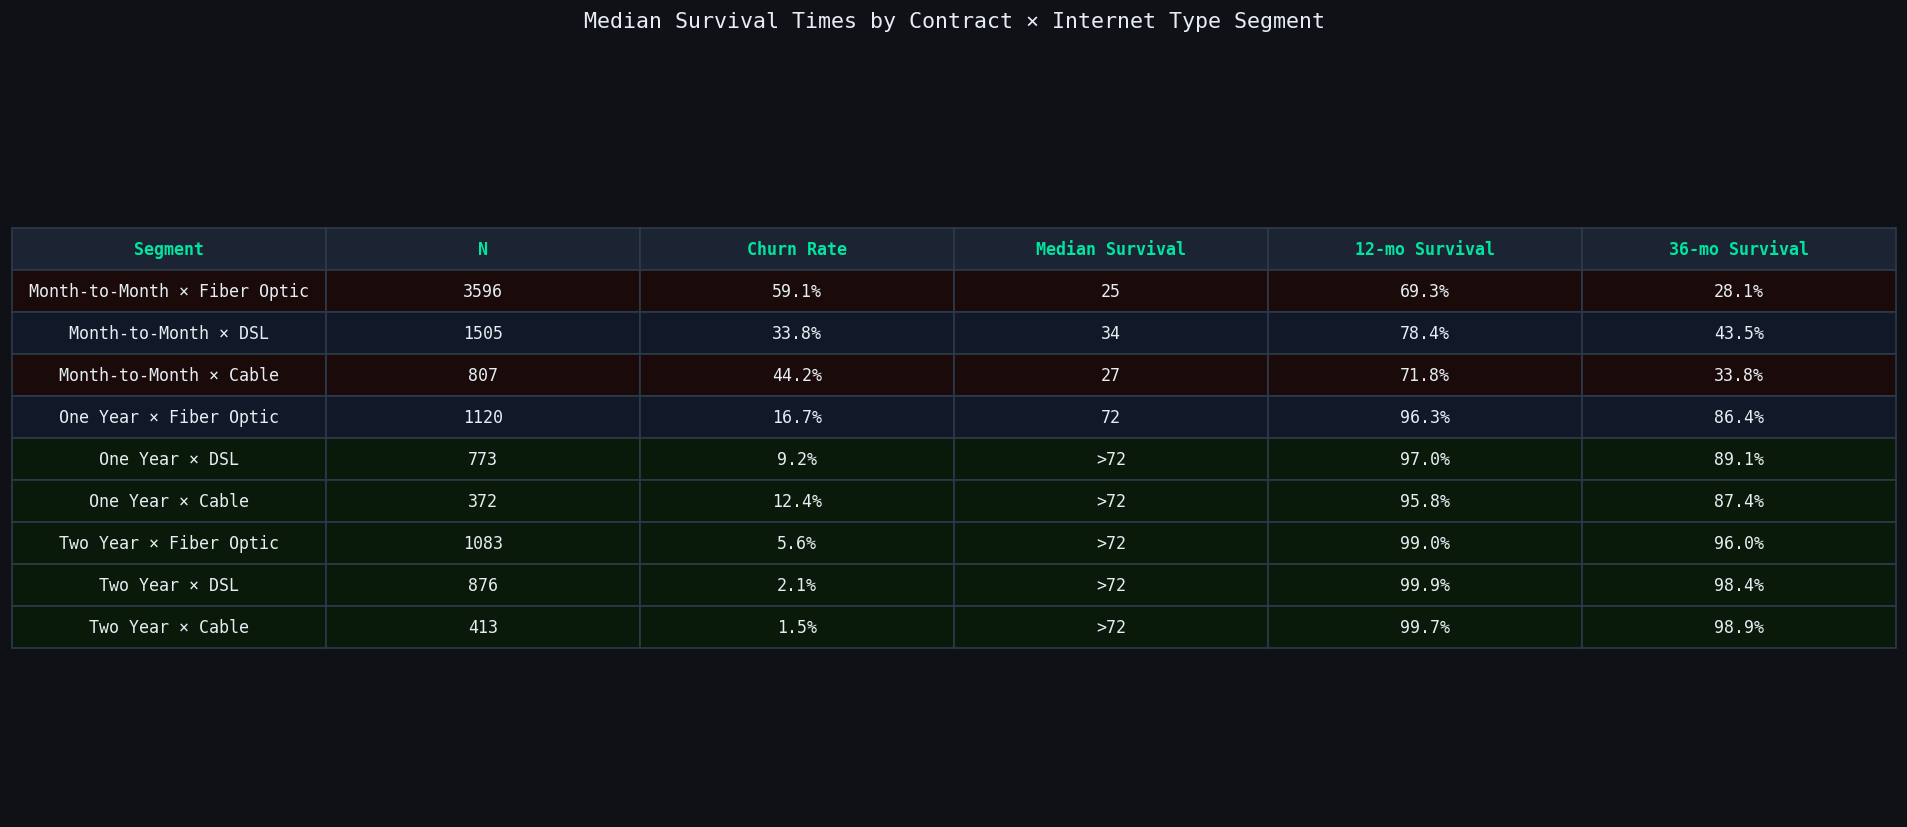

                     Segment    N Churn Rate Median Survival 12-mo Survival 36-mo Survival
Month-to-Month × Fiber Optic 3596      59.1%              25          69.3%          28.1%
        Month-to-Month × DSL 1505      33.8%              34          78.4%          43.5%
      Month-to-Month × Cable  807      44.2%              27          71.8%          33.8%
      One Year × Fiber Optic 1120      16.7%              72          96.3%          86.4%
              One Year × DSL  773       9.2%             >72          97.0%          89.1%
            One Year × Cable  372      12.4%             >72          95.8%          87.4%
      Two Year × Fiber Optic 1083       5.6%             >72          99.0%          96.0%
              Two Year × DSL  876       2.1%             >72          99.9%          98.4%
            Two Year × Cable  413       1.5%             >72          99.7%          98.9%

✅ Saved: outputs/survival_segments.csv


In [17]:
# Build comprehensive segment table
segments = []

# Contract × Internet Type
for contract in ["Month-to-Month","One Year","Two Year"]:
    for itype in ["Fiber Optic","DSL","Cable"]:
        mask = (df["contract"]==contract) & (df["internet_type"]==itype)
        if mask.sum() < 30: continue
        t,s,_,_ = kaplan_meier(DURATION[mask], EVENT[mask])
        segments.append({
            "Segment":          f"{contract} × {itype}",
            "N":                mask.sum(),
            "Churn Rate":       f"{EVENT[mask].mean()*100:.1f}%",
            "Median Survival":  median_survival(t,s),
            "12-mo Survival":   f"{survival_at(t,s,12)*100:.1f}%",
            "36-mo Survival":   f"{survival_at(t,s,36)*100:.1f}%",
        })

seg_df = pd.DataFrame(segments)

# ── Visual table ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor("#0f1117"); ax.axis("off")

cols = list(seg_df.columns)
rows = seg_df.values.tolist()

table = ax.table(
    cellText=rows, colLabels=cols,
    cellLoc="center", loc="center")

table.auto_set_font_size(False); table.set_fontsize(10)
table.scale(1, 1.8)

# Style header
for j in range(len(cols)):
    cell = table[0,j]
    cell.set_facecolor("#1c2333"); cell.set_text_props(color=GREEN, fontweight="bold")
    cell.set_edgecolor("#2d3a4a")

# Style data rows — colour by churn rate
for i, row in enumerate(rows):
    churn_val = float(row[2].replace("%",""))
    row_color = "#1a0a0a" if churn_val > 40 else "#0a1a0a" if churn_val < 15 else "#111827"
    for j in range(len(cols)):
        cell = table[i+1,j]
        cell.set_facecolor(row_color)
        cell.set_edgecolor("#2d3a4a")
        cell.set_text_props(color="#e6edf3")

ax.set_title("Median Survival Times by Contract × Internet Type Segment",
             fontsize=13, pad=20, color="#e6edf3")
plt.tight_layout()
plt.savefig("../outputs/08_median_survival_times.png",
            bbox_inches="tight", facecolor="#0f1117")
plt.show()

print(seg_df.to_string(index=False))

# Save to CSV
seg_df.to_csv("../outputs/survival_segments.csv", index=False)
print("\n✅ Saved: outputs/survival_segments.csv")


## 10 · Early Warning — The Critical First 12 Months

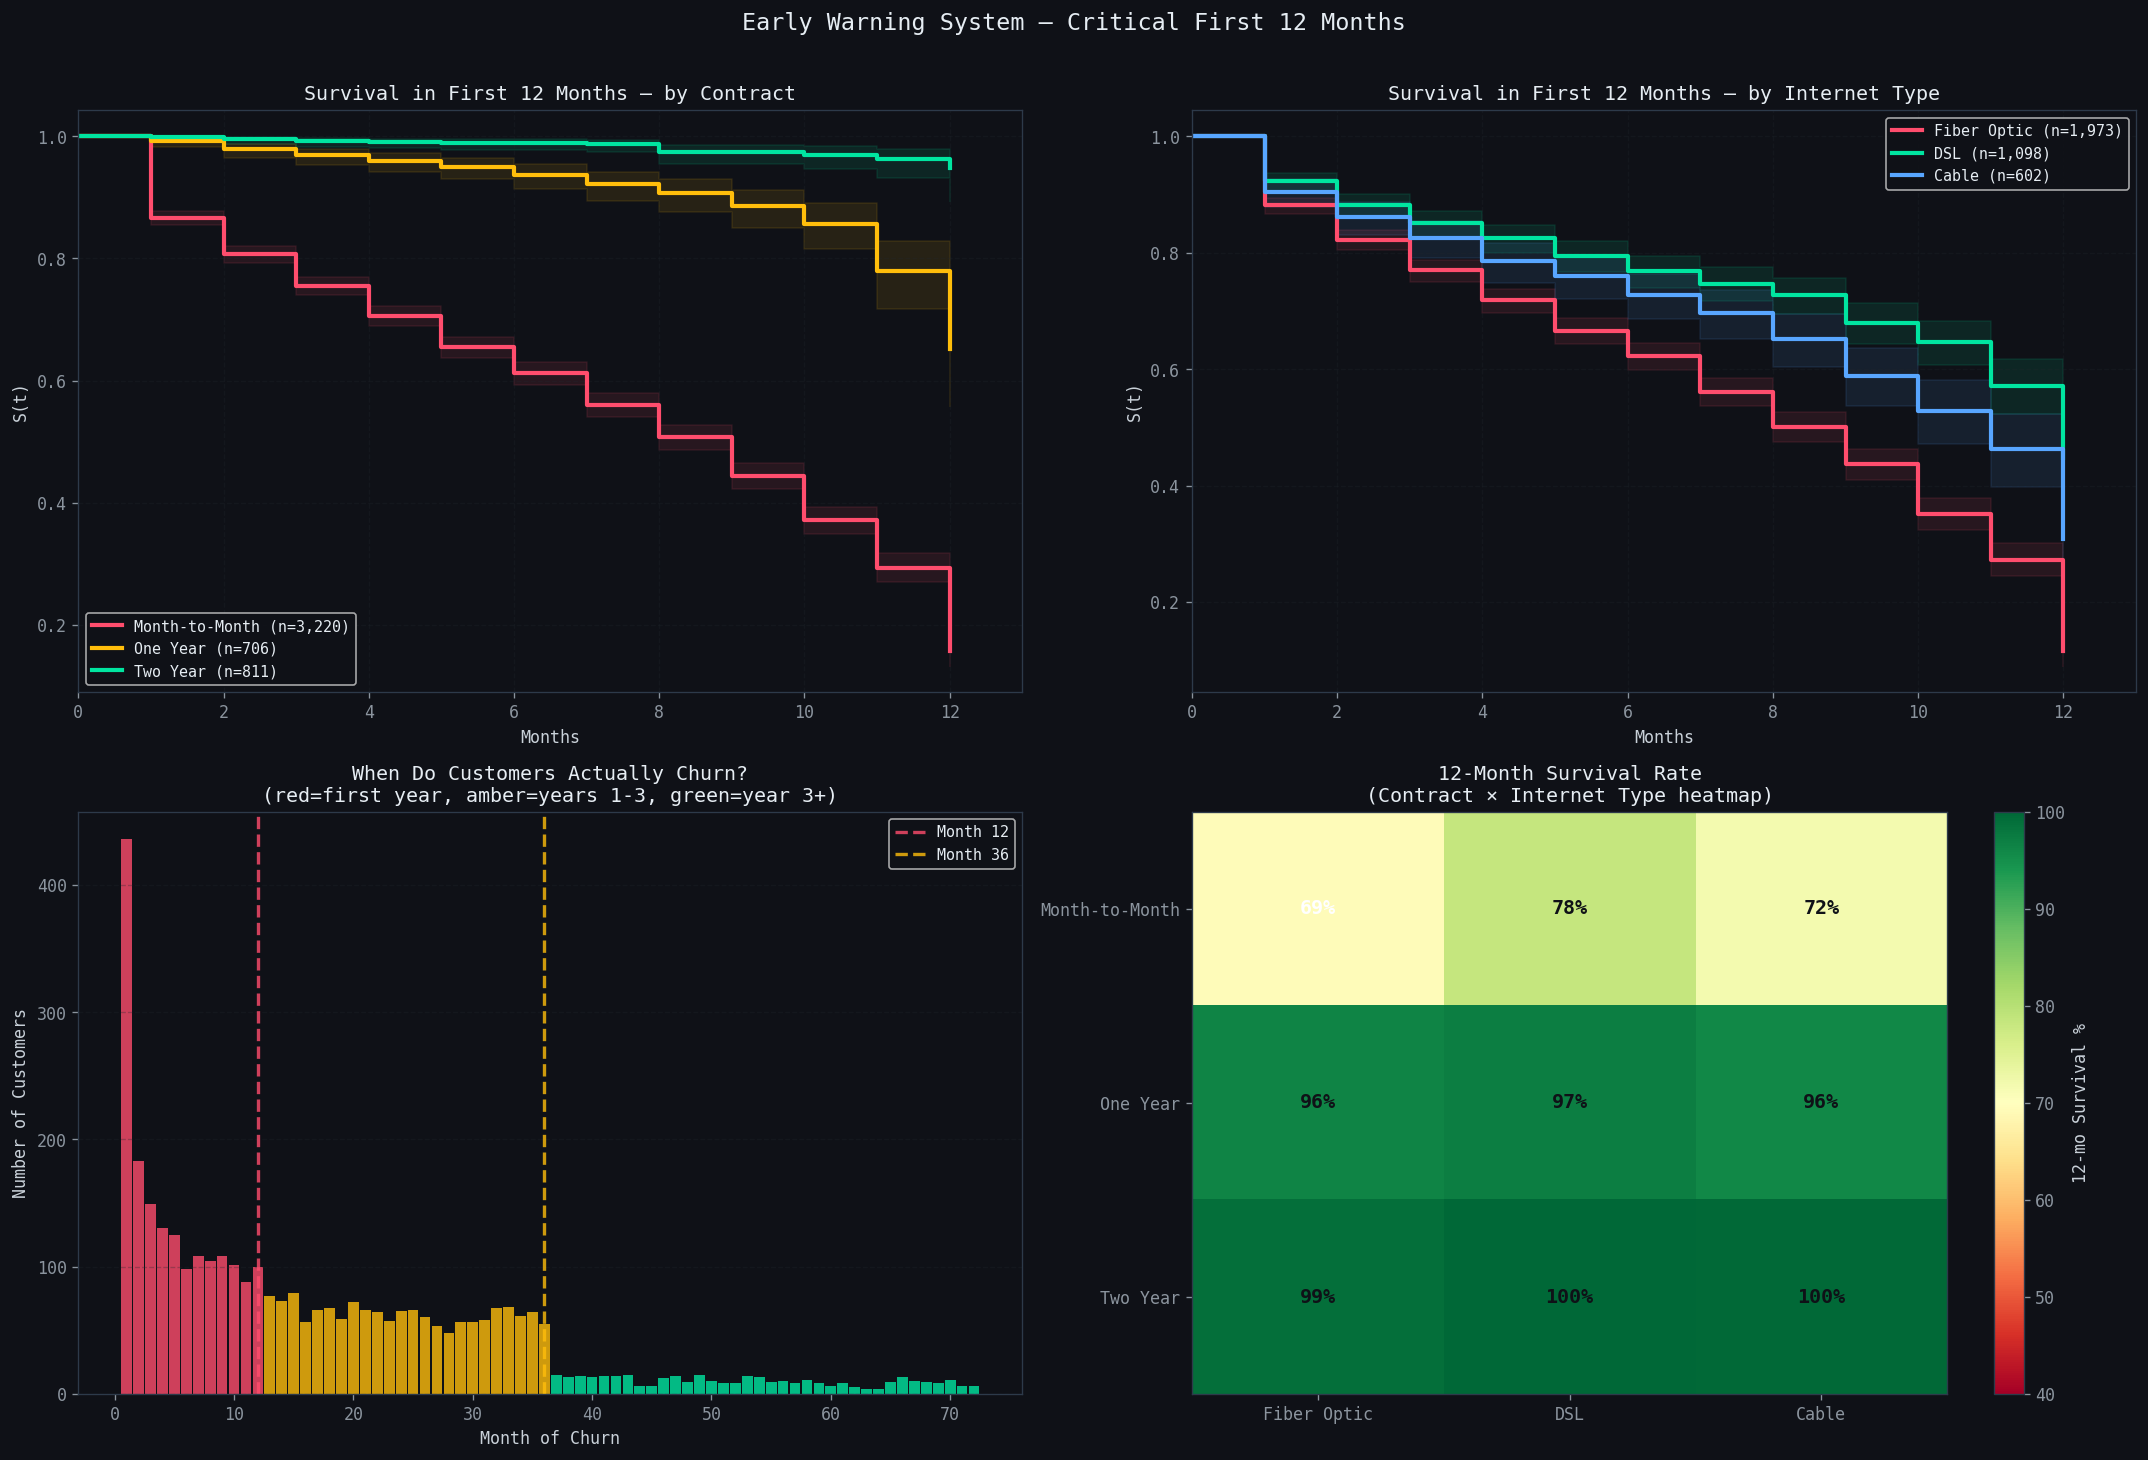

Highest-risk combinations (12-month survival):
                Fiber Optic        DSL      Cable
Month-to-Month    69.304378  78.366397  71.813059
One Year          96.349771  96.960399  95.819052
Two Year          98.986346  99.882629  99.697885


In [18]:
# Focus on customers in their first year — highest churn hazard window
early = df[df["tenure_in_months"] <= 12].copy()
early_d = early["tenure_in_months"].values
early_e = early["churn"].values

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor("#0f1117")

# Plot 1: Early survival by contract
ax = axes[0,0]
for contract, color in zip(contracts, colors_c):
    mask = early["contract"] == contract
    if mask.sum() < 10: continue
    t,s,lo,hi = kaplan_meier(early_d[mask], early_e[mask])
    ax.step(t,s,where="post",color=color,lw=2.5,
            label=f"{contract} (n={mask.sum():,})")
    ax.fill_between(t,lo,hi,step="post",alpha=0.1,color=color)
ax.set_title("Survival in First 12 Months — by Contract")
ax.set_xlabel("Months"); ax.set_ylabel("S(t)")
ax.legend(fontsize=9); ax.grid(True,alpha=0.3); ax.set_xlim(0,13)

# Plot 2: Early survival by internet type
ax = axes[0,1]
for itype, color in zip(internet_types, colors_i):
    mask = early["internet_type"] == itype
    if mask.sum() < 10: continue
    t,s,lo,hi = kaplan_meier(early_d[mask], early_e[mask])
    ax.step(t,s,where="post",color=color,lw=2.5,
            label=f"{itype} (n={mask.sum():,})")
    ax.fill_between(t,lo,hi,step="post",alpha=0.1,color=color)
ax.set_title("Survival in First 12 Months — by Internet Type")
ax.set_xlabel("Months"); ax.set_ylabel("S(t)")
ax.legend(fontsize=9); ax.grid(True,alpha=0.3); ax.set_xlim(0,13)

# Plot 3: Monthly churn count (when do customers leave?)
ax = axes[1,0]
churned = df[df["churn"]==1]["tenure_in_months"]
bins = np.arange(1,74)
counts,_ = np.histogram(churned, bins=bins)
colors_bar = [RED if b<=12 else AMBER if b<=36 else GREEN for b in bins[:-1]]
ax.bar(bins[:-1], counts, color=colors_bar, alpha=0.8, width=0.9)
ax.set_xlabel("Month of Churn"); ax.set_ylabel("Number of Customers")
ax.set_title("When Do Customers Actually Churn?\n(red=first year, amber=years 1-3, green=year 3+)")
ax.axvline(12, color=RED,  lw=2, linestyle="--", alpha=0.8, label="Month 12")
ax.axvline(36, color=AMBER,lw=2, linestyle="--", alpha=0.8, label="Month 36")
ax.legend(fontsize=9); ax.grid(True,axis="y",alpha=0.3)

# Plot 4: 6-month survival heatmap by contract × internet type
ax = axes[1,1]
pivot_data = {}
for contract in ["Month-to-Month","One Year","Two Year"]:
    pivot_data[contract] = {}
    for itype in ["Fiber Optic","DSL","Cable"]:
        mask = (df["contract"]==contract) & (df["internet_type"]==itype)
        if mask.sum() < 20:
            pivot_data[contract][itype] = np.nan
            continue
        t,s,_,_ = kaplan_meier(DURATION[mask], EVENT[mask])
        pivot_data[contract][itype] = survival_at(t,s,12)*100

heatmap_df = pd.DataFrame(pivot_data).T
im = ax.imshow(heatmap_df.values, cmap="RdYlGn", vmin=40, vmax=100, aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(heatmap_df.columns, fontsize=10)
ax.set_yticks(range(3)); ax.set_yticklabels(heatmap_df.index, fontsize=10)
for i in range(3):
    for j in range(3):
        val = heatmap_df.iloc[i,j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                    fontsize=12, fontweight="bold",
                    color="white" if val < 70 else "#0f1117")
ax.set_title("12-Month Survival Rate\n(Contract × Internet Type heatmap)")
plt.colorbar(im, ax=ax, label="12-mo Survival %")

plt.suptitle("Early Warning System — Critical First 12 Months",
             fontsize=14, y=1.01, color="#e6edf3")
plt.tight_layout()
plt.savefig("../outputs/08_early_warning.png",
            bbox_inches="tight", facecolor="#0f1117")
plt.show()

print("Highest-risk combinations (12-month survival):")
print(heatmap_df.to_string())


## 11 · Summary — Key Survival Insights

In [19]:
print("=" * 65)
print("  SURVIVAL ANALYSIS — KEY FINDINGS")
print("=" * 65)

print("\n📍 Overall:")
print(f"   12-month survival: {survival_at(t_all,s_all,12):.1%}")
print(f"   36-month survival: {survival_at(t_all,s_all,36):.1%}")
print(f"   72-month survival: {survival_at(t_all,s_all,72):.1%}")

print("\n📋 By Contract — Median Survival:")
for c,d in km_data.items():
    print(f"   {c:<18}: {d['med']} months")

print("\n🌐 By Internet Type — 12-Month Survival:")
for it,d in km_int.items():
    print(f"   {it:<14}: {survival_at(d['t'],d['s'],12):.1%}")

print("\n🎯 Risk Tier Validation:")
for d in tier_stats:
    print(f"   {d['tier']:<14}: predicted={d['predicted']:.1%}  actual={d['actual']:.1%}")

print("\n⚡ Top Hazard Ratio (Cox):")
print(f"   #{1}: {hr_df.iloc[0]['feature']} (HR={hr_df.iloc[0]['hazard_ratio']:.2f})")
print(f"   #{2}: {hr_df.iloc[1]['feature']} (HR={hr_df.iloc[1]['hazard_ratio']:.2f})")
print(f"   Most protective: {hr_df.iloc[-1]['feature']} (HR={hr_df.iloc[-1]['hazard_ratio']:.2f})")

outputs = ["08_overall_survival.png","08_kaplan_meier_by_contract.png",
           "08_kaplan_meier_by_internet.png","08_survival_risk_tiers.png",
           "08_cox_hazard_ratios.png","08_median_survival_times.png",
           "08_early_warning.png","survival_segments.csv"]
print("\n✅ Saved outputs:")
for f in outputs:
    print(f"   {'✅' if __import__('os').path.exists(f'../outputs/{f}') else '⬜'} {f}")


  SURVIVAL ANALYSIS — KEY FINDINGS

📍 Overall:
   12-month survival: 85.8%
   36-month survival: 65.1%
   72-month survival: 51.6%

📋 By Contract — Median Survival:
   Month-to-Month    : 29 months
   One Year          : >72 months
   Two Year          : >72 months

🌐 By Internet Type — 12-Month Survival:
   Fiber Optic   : 80.0%
   DSL           : 89.2%
   Cable         : 85.0%

🎯 Risk Tier Validation:
   High Risk     : predicted=93.1%  actual=97.3%
   Medium Risk   : predicted=43.8%  actual=42.0%
   Low Risk      : predicted=2.5%  actual=1.6%

⚡ Top Hazard Ratio (Cox):
   #1: is_m2m (HR=3.95)
   #2: monthly_charge (HR=1.92)
   Most protective: total_revenue (HR=0.59)

✅ Saved outputs:
   ✅ 08_overall_survival.png
   ✅ 08_kaplan_meier_by_contract.png
   ✅ 08_kaplan_meier_by_internet.png
   ✅ 08_survival_risk_tiers.png
   ✅ 08_cox_hazard_ratios.png
   ✅ 08_median_survival_times.png
   ✅ 08_early_warning.png
   ✅ survival_segments.csv
